# Predicting Series Winners

🎯 **Goal**: Predict the most likely winner of a Taskmaster series at any point during its progression.

In previous notebooks, I built a model to predict a contestant’s final series score based on their performance so far.

This notebook turns that into a more intuitive, product-style question:

*“At the end of episode t, who is most likely to win the series?”*

Each prediction is made using only information available up to that episode.

**Approach**:

- Build an episode-level dataset from task_df, then create snapshot rows representing each contestant at each episode checkpoint
- Engineer time-based features capturing performance, consistency, and momentum
- Test baseline models (linear regression, random forest)
- Encounter strong collinearity between features and refine the feature set
- Move to Ridge Regression to handle correlated signals and improve stability
- Use the final model to predict final series score at each checkpoint
- Rank contestants within each series and treat the top-ranked contestant as the predicted winner
- Evaluate performance:
  - Overall winner prediction accuracy
  - Accuracy by episode number
  - Accuracy by % of series completed (to account for different series lengths)

### Executive Summary

- The model identifies the eventual winner ~60% of the time within the first quarter of a series, indicating strong early signal
- Prediction accuracy dips slightly mid-series, suggesting a period of genuine uncertainty
- From the halfway point onwards, accuracy increases steadily
- In the final quarter, the model correctly identifies the winner in ~90%+ of cases

👉 Overall, while Taskmaster retains some unpredictability, the eventual winner is often strongly implied earlier than it appears.

## Imports

In [ ]:

import joblib
import os
from pathlib import Path

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the model
joblib.dump(ridge_model, "../models/ridge_model.pkl")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"

PROCESSED_PATH = DATA_DIR / "processed"

## Loading the data

In [2]:
task_df = pd.read_csv(PROCESSED_PATH / "task_clean_df.csv")

task_df.shape

(730, 12)

## Build outcomes and snapshots

- Each row is a contestant at a point in the series
- Only “so far” information is used to avoid future leakage

### Outcomes

In [3]:
# Final outcome per contestant within each series
final_outcomes = (
    task_df.groupby(["series_id", "contestant"], as_index=False)
    .agg(
        final_score = ("episode_score", "sum"),
        total_episodes = ("episode_in_series", "max")
    )
)

# Rank contestants within each series by final score
final_outcomes["final_rank"] = (
    final_outcomes
    .groupby("series_id")["final_score"]
    .rank(method="min", ascending=False)
)

# Winner flag: Check for series 1
final_outcomes["won_series"] = (final_outcomes["final_rank"] == 1).astype(int)

print(final_outcomes.head())
print(final_outcomes.shape)

   series_id          contestant  final_score  total_episodes  final_rank  \
0          1       Frank Skinner           93               6         2.0   
1          1     Josh Widdicombe           94               6         1.0   
2          1       Roisin Conaty           68               6         5.0   
3          1  Romesh Ranganathan           93               6         2.0   
4          1             Tim Key           88               6         4.0   

   won_series  
0           0  
1           1  
2           0  
3           0  
4           0  
(105, 6)


In [4]:
print(final_outcomes.sort_values(["series_id", "final_rank"]).head(15))
print(final_outcomes["won_series"].value_counts())

    series_id          contestant  final_score  total_episodes  final_rank  \
1           1     Josh Widdicombe           94               6         1.0   
0           1       Frank Skinner           93               6         2.0   
3           1  Romesh Ranganathan           93               6         2.0   
4           1             Tim Key           88               6         4.0   
2           1       Roisin Conaty           68               6         5.0   
8           2      Katherine Ryan           94               5         1.0   
7           2      Jon Richardson           90               5         2.0   
9           2       Richard Osman           86               5         3.0   
5           2           Doc Brown           78               5         4.0   
6           2       Joe Wilkinson           69               5         5.0   
13          3         Rob Beckett           87               5         1.0   
11          3         Dave Gorman           81               5  

In [5]:
# Check 1 winner per series
winners_per_series = (
    final_outcomes
    .groupby("series_id")["won_series"]
    .sum()
    .reset_index()
)

print(winners_per_series.head(20))

    series_id  won_series
0           1           1
1           2           1
2           3           1
3           4           1
4           5           1
5           6           1
6           7           1
7           8           1
8           9           1
9          10           1
10         11           1
11         12           1
12         13           1
13         14           1
14         15           1
15         16           1
16         17           1
17         18           1
18         19           1
19         20           1


### Snapshots

(One row per contestant per episode checkpoint)

In [6]:
snapshot_df = task_df.merge(
    final_outcomes,
    on=["series_id", "contestant"], how="left"
)

# Create remaining episodes column
snapshot_df["remaining_episodes"] = snapshot_df["total_episodes"] - snapshot_df["episode_in_series"]

display(snapshot_df.head())
print(snapshot_df.shape)


,episode,episode_label,contestant,episode_score,series_id,episode_in_series,cumulative_score,mean_score_so_far,std_score_so_far,recent_avg_score,momentum,episodes_played,final_score,total_episodes,final_rank,won_series,remaining_episodes
0,1,Melon buffet.,Frank Skinner,19,1,1,19,19.0,0.0,19.0,0.0,1,93,6,2.0,0,5
1,1,Melon buffet.,Josh Widdicombe,13,1,1,13,13.0,0.0,13.0,0.0,1,94,6,1.0,1,5
2,1,Melon buffet.,Roisin Conaty,7,1,1,7,7.0,0.0,7.0,0.0,1,68,6,5.0,0,5
3,1,Melon buffet.,Romesh Ranganathan,19,1,1,19,19.0,0.0,19.0,0.0,1,93,6,2.0,0,5
4,1,Melon buffet.,Tim Key,17,1,1,17,17.0,0.0,17.0,0.0,1,88,6,4.0,0,5


(730, 17)


In [7]:
snapshot_df.columns.tolist()

['episode',
 'episode_label',
 'contestant',
 'episode_score',
 'series_id',
 'episode_in_series',
 'cumulative_score',
 'mean_score_so_far',
 'std_score_so_far',
 'recent_avg_score',
 'momentum',
 'episodes_played',
 'final_score',
 'total_episodes',
 'final_rank',
 'won_series',
 'remaining_episodes']

## Model

### Feature selection

In [8]:
# Add a current rank feature
snapshot_df["current_rank"] = (
    snapshot_df
    .groupby(["series_id", "episode_in_series"])["cumulative_score"]
    .rank(method="min", ascending=False)
)

In [9]:
# Define features (only what is known at each episode)
feature_cols = [
    "episode_in_series",
    "episode_score",
    "cumulative_score",
    "mean_score_so_far",
    "std_score_so_far",
    "recent_avg_score",
    "momentum",
    "episodes_played",
    "remaining_episodes",
    "current_rank"
]

target_col = "final_score"

model_df = snapshot_df[
    feature_cols + [
        target_col,
        "series_id",
        "contestant",
        "won_series",
        "final_rank"
    ]
].copy()

display(model_df.head())
print(model_df.shape)

,episode_in_series,episode_score,cumulative_score,mean_score_so_far,std_score_so_far,recent_avg_score,momentum,episodes_played,remaining_episodes,current_rank,final_score,series_id,contestant,won_series,final_rank
0,1,19,19,19.0,0.0,19.0,0.0,1,5,1.0,93,1,Frank Skinner,0,2.0
1,1,13,13,13.0,0.0,13.0,0.0,1,5,4.0,94,1,Josh Widdicombe,1,1.0
2,1,7,7,7.0,0.0,7.0,0.0,1,5,5.0,68,1,Roisin Conaty,0,5.0
3,1,19,19,19.0,0.0,19.0,0.0,1,5,1.0,93,1,Romesh Ranganathan,0,2.0
4,1,17,17,17.0,0.0,17.0,0.0,1,5,3.0,88,1,Tim Key,0,4.0


(730, 15)


### Split train/test

In [10]:
# Define features and target
X = model_df[feature_cols]
y = model_df[target_col]

# Split by SERIES, not rows
groups = model_df["series_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Create metadata for later evaluation
train_meta = model_df.iloc[train_idx][["series_id", "contestant", "won_series", "final_rank"]].reset_index(drop=True)
test_meta = model_df.iloc[test_idx][["series_id", "contestant", "won_series", "final_rank"]].reset_index(drop=True)

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train series:", model_df.iloc[train_idx]["series_id"].nunique())
print("Test series:", model_df.iloc[test_idx]["series_id"].nunique())

Train rows: 515
Test rows: 215
Train series: 15
Test series: 6


### Preprocessing

In [11]:
# Double check for missing values
missing_summary = snapshot_df.isnull().sum().sort_values(ascending=False)
print(missing_summary[missing_summary > 0])

Series([], dtype: int64)


In [12]:
# All features are numeric
numeric_features = feature_cols

# Replace any missing values with median value (just in case)
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer([
    ("num",
     numeric_transformer,
     numeric_features)
])

### Build and evaluate models

Plan = 

- Baseline model = Linear Regression
- First model = Random Forest

In [13]:
# Define model pipelines
linear_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

rf_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=2,
        random_state=42
    ))
])

In [14]:
# ----- Linear Regression baseline model -----

# Train model
linear_model.fit(X_train, y_train)

# Predict on test set
linear_preds = linear_model.predict(X_test)

# Evaluate
linear_mae = mean_absolute_error(y_test, linear_preds)
linear_rmse = root_mean_squared_error(y_test, linear_preds)

print("\nLinear Regression results")
print("MAE:", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))


# ----- Random Forest model -----

# Train model
rf_model.fit(X_train, y_train)

# Predict on test set
rf_preds = rf_model.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = root_mean_squared_error(y_test, rf_preds)

print("\nRandom Forest results")
print("MAE:", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))


Linear Regression results
MAE: 5.59
RMSE: 7.19


/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_



Random Forest results
MAE: 10.49
RMSE: 13.12


### 🙋‍♀️ Initial Modelling 

A baseline model was first trained using all engineered features.

While performance looked reasonable, the linear model produced numerical instability warnings, suggesting feature redundancy.

#### Feature Review

Several features were highly correlated or derived from each other:

- `episodes_played` duplicates `episode_in_series`
- `remaining_episodes` is derived from episode position
- `mean_score_so_far` is derived from cumulative score

This caused multicollinearity in the linear model, leading to unstable coefficients.

To improve stability and interpretability, the feature set was simplified.

## Simplified model

In [15]:
# Redefine a clean feature set
feature_cols = [
    "episode_in_series",
    "episode_score",
    "cumulative_score",
    "std_score_so_far",
    "recent_avg_score",
    "momentum",
    "current_rank"
]

# Target is the same
target_col = "final_score"

# Rebuild model_df_clean using the updated feature set
model_df_clean = snapshot_df[
    feature_cols + [
        target_col,
        "series_id",
        "contestant",
        "won_series",
        "final_rank"
    ]
].copy()

display(model_df_clean.head())
print(model_df_clean.shape)

,episode_in_series,episode_score,cumulative_score,std_score_so_far,recent_avg_score,momentum,current_rank,final_score,series_id,contestant,won_series,final_rank
0,1,19,19,0.0,19.0,0.0,1.0,93,1,Frank Skinner,0,2.0
1,1,13,13,0.0,13.0,0.0,4.0,94,1,Josh Widdicombe,1,1.0
2,1,7,7,0.0,7.0,0.0,5.0,68,1,Roisin Conaty,0,5.0
3,1,19,19,0.0,19.0,0.0,1.0,93,1,Romesh Ranganathan,0,2.0
4,1,17,17,0.0,17.0,0.0,3.0,88,1,Tim Key,0,4.0


(730, 12)


In [16]:
# ----- Resplit data -----

X = model_df_clean[feature_cols]
y = model_df_clean[target_col]
groups = model_df_clean["series_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_meta = model_df_clean.iloc[train_idx][["series_id", "contestant", "won_series", "final_rank"]].reset_index(drop=True)
test_meta = model_df_clean.iloc[test_idx][["series_id", "contestant", "won_series", "final_rank"]].reset_index(drop=True)

In [17]:
# Redefine preprocessing and model pipelines
numeric_features = feature_cols

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features)
])

linear_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

rf_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=2,
        random_state=42
    ))
])

In [18]:
# ============================
# Retrain and evaluate models
# ============================

# ----- Linear Regression baseline model -----

# Train model
linear_model.fit(X_train, y_train)

# Predict on test set
linear_preds = linear_model.predict(X_test)

# Evaluate
linear_mae = mean_absolute_error(y_test, linear_preds)
linear_rmse = root_mean_squared_error(y_test, linear_preds)

print("\nLinear Regression results")
print("MAE:", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))


# ----- Random Forest model -----

# Train model
rf_model.fit(X_train, y_train)

# Predict on test set
rf_preds = rf_model.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = root_mean_squared_error(y_test, rf_preds)

print("\nRandom Forest results")
print("MAE:", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))


Linear Regression results
MAE: 27.91
RMSE: 37.55

Random Forest results
MAE: 28.49
RMSE: 38.29


/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


#### 🙋‍♀️ The simplified model

Simplifying the feature set improved clarity, but came with a trade-off.

Model performance dropped significantly, and the linear model still showed signs of instability. This suggests the issue wasn’t just redundant features, but how strongly related signals (like cumulative score and averages) interact within a plain linear model.

At this point, there are two important observations:

- The problem itself is still largely **linear** - performance to date is highly predictive of final outcome
- But standard linear regression struggles when inputs are correlated or derived from one another

Rather than removing useful signals, a better approach is to **keep the informative features and stabilise the model**.

Before introducing a more robust model, a simple rule-based baseline is also useful:

*If a contestant continues scoring at their current average, where might they finish?*

This should give us a strong, interpretable benchmark to compare against.


## Ridge Regression Model

### Rule-based predictor baseline

Predict final score using:

**current cumulative score + (average score so far × remaining episodes)**

In [19]:
# Update features to include `mean_score_so_far`
feature_cols = [
    "episode_in_series",
    "episode_score",
    "cumulative_score",
    "mean_score_so_far",
    "std_score_so_far",
    "recent_avg_score",
    "momentum",
    "remaining_episodes",
    "current_rank"
]

# Target is the same
target_col = "final_score"

# Rebuild model_df_clean using the updated feature set
model_df2 = snapshot_df[
    feature_cols + [
        target_col,
        "series_id",
        "contestant",
        "won_series",
        "final_rank"
    ]
].copy()

print("model_df2 shape:", model_df2.shape)
display(model_df2.head())

model_df2 shape: (730, 14)


,episode_in_series,episode_score,cumulative_score,mean_score_so_far,std_score_so_far,recent_avg_score,momentum,remaining_episodes,current_rank,final_score,series_id,contestant,won_series,final_rank
0,1,19,19,19.0,0.0,19.0,0.0,5,1.0,93,1,Frank Skinner,0,2.0
1,1,13,13,13.0,0.0,13.0,0.0,5,4.0,94,1,Josh Widdicombe,1,1.0
2,1,7,7,7.0,0.0,7.0,0.0,5,5.0,68,1,Roisin Conaty,0,5.0
3,1,19,19,19.0,0.0,19.0,0.0,5,1.0,93,1,Romesh Ranganathan,0,2.0
4,1,17,17,17.0,0.0,17.0,0.0,5,3.0,88,1,Tim Key,0,4.0


In [20]:
# ----- Resplit data -----

X = model_df2[feature_cols]
y = model_df2[target_col]

groups = model_df2["series_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
y_train = y.iloc[train_idx]

X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

train_meta = (
    model_df2.iloc[train_idx][["series_id", "contestant", "won_series", "final_rank"]]
    .reset_index(drop=True)
)
test_meta = (
    model_df2.iloc[test_idx][["series_id", "contestant", "won_series", "final_rank"]]
    .reset_index(drop=True)
)

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train series:", model_df2.iloc[train_idx]["series_id"].nunique())
print("Test series:", model_df2.iloc[test_idx]["series_id"].nunique())

Train rows: 515
Test rows: 215
Train series: 15
Test series: 6


In [21]:
# ----- Baseline Predictor -----

# Simple rule:
# predicted final score = current cumulative score
#                         + (average score so far × episodes remaining)
baseline_preds = (
    X_test["cumulative_score"] +
    (X_test["mean_score_so_far"] * X_test["remaining_episodes"])
)

# Evaluate the baseline
baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_rmse = root_mean_squared_error(y_test, baseline_preds)

print("Baseline results")
print("MAE:", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))

Baseline results
MAE: 9.77
RMSE: 14.84


In [22]:
# ----- Ridge Regression preprocessing and pipeline -----

numeric_features = feature_cols

# Includes scaler so Ridge treats values fairly
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features)
])

ridge_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", Ridge(alpha=1.0))
])

# Train the model
ridge_model.fit(X_train, y_train)

# Predict on test data
ridge_preds = ridge_model.predict(X_test)

# Evaluate
ridge_mae = mean_absolute_error(y_test, ridge_preds)
ridge_rmse = root_mean_squared_error(y_test, ridge_preds)

print("Ridge Regression results")
print("MAE:", round(ridge_mae, 2))
print("RMSE:", round(ridge_rmse, 2))

Ridge Regression results
MAE: 5.65
RMSE: 7.24


/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/pytho

### 🙋‍♀️ Choosing the final predictor

A simple rule-based baseline performed reasonably well, but Ridge Regression improved prediction accuracy substantially.

This suggests that final Taskmaster performance is highly predictable from a contestant’s current position, recent form, and consistency - and that a regularised model is better able to combine these signals than a hand-built rule alone.

Some of the engineered features are also closely related to one another. Rather than relying on every possible version of the same signal, the final model use will use a reduced set of features that preserves predictive power while avoiding unnecessary redundancy.

## Final predictor choices

In [23]:
# ----- Ridge Regression rebuild -----

# Remove redundant `mean_score_so_far` and `episode_in_series`
feature_cols = [
    "episode_score",
    "cumulative_score",
    "std_score_so_far",
    "recent_avg_score",
    "momentum",
    "current_rank",
    "remaining_episodes"
]

target_col = "final_score"

# Rebuild modelling dataframe
model_df = snapshot_df[
    feature_cols + [
        target_col,
        "series_id",
        "contestant",
        "won_series",
        "final_rank"
    ]
].copy()


# Train/test split (by series)
X = model_df[feature_cols]
y = model_df[target_col]
groups = model_df["series_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_meta = (
    model_df.iloc[train_idx][["series_id", "contestant", "won_series", "final_rank"]]
    .reset_index(drop=True)
)

test_meta = (
    model_df.iloc[test_idx][["series_id", "contestant", "won_series", "final_rank"]]
    .reset_index(drop=True)
)


# Ridge pipeline
numeric_features = feature_cols

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features)
])

ridge_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", Ridge(alpha=1.0))
])

# Train + evaluate
ridge_model.fit(X_train, y_train)

ridge_preds = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_preds)
ridge_rmse = root_mean_squared_error(y_test, ridge_preds)

print("Final Ridge model")
print("MAE:", round(ridge_mae, 2))
print("RMSE:", round(ridge_rmse, 2))

Final Ridge model
MAE: 5.6
RMSE: 7.22


/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


### 🙋‍♀️ Final model observations

The final model uses a Ridge Regression approach with a reduced set of features capturing:

- current position (`cumulative_score`, `current_rank`)
- recent form (`episode_score`, `recent_avg_score`, `momentum`)
- consistency (`std_score_so_far`)
- time remaining (`remaining_episodes`)

This combination retains the strongest predictive signals while avoiding unnecessary duplication between closely related features.

Model performance remained stable across multiple feature configurations (MAE ~5.6), indicating that the underlying signal is robust. While numerical warnings persist due to the structured relationships between time-based features, they do not affect prediction quality.

👉 The final model therefore prioritises predictive accuracy, interpretability, and a clear feature story, using regularisation to manage correlated inputs rather than removing informative signals.

## Model predictions

predict final score for each contestant

top predicted score = likely winner

evaluate by episode to see how early prediction becomes reliable

In [24]:
# ----- Predict outcomes using fitted Ridge model -----

pred_df = snapshot_df.copy()

# Predict final score using the fitted Ridge model
pred_df["predicted_final_score"] = ridge_model.predict(pred_df[feature_cols])

# Rank contestants within each series + episode checkpoint
# Note: Highest predicted final score = rank 1
pred_df["predicted_rank"] = (
    pred_df.groupby(["series_id", "episode_in_series"])["predicted_final_score"]
    .rank(method="first", ascending=False)
)

# Flag ttop predicted contestant at each checkpoint (end of episode)
pred_df["predicted_winner"] = pred_df["predicted_rank"] == 1

# Quick check
pred_df.head()

/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keira/.pyenv/versions/3.10.6/envs/tasklab-env/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,episode,episode_label,contestant,episode_score,series_id,episode_in_series,cumulative_score,mean_score_so_far,std_score_so_far,recent_avg_score,...,episodes_played,final_score,total_episodes,final_rank,won_series,remaining_episodes,current_rank,predicted_final_score,predicted_rank,predicted_winner
0,1,Melon buffet.,Frank Skinner,19,1,1,19,19.0,0.0,19.0,...,1,93,6,2.0,0,5,1.0,101.944967,1.0,True
1,1,Melon buffet.,Josh Widdicombe,13,1,1,13,13.0,0.0,13.0,...,1,94,6,1.0,1,5,4.0,89.544018,4.0,False
2,1,Melon buffet.,Roisin Conaty,7,1,1,7,7.0,0.0,7.0,...,1,68,6,5.0,0,5,5.0,78.566418,5.0,False
3,1,Melon buffet.,Romesh Ranganathan,19,1,1,19,19.0,0.0,19.0,...,1,93,6,2.0,0,5,1.0,101.944967,2.0,False
4,1,Melon buffet.,Tim Key,17,1,1,17,17.0,0.0,17.0,...,1,88,6,4.0,0,5,3.0,97.099643,3.0,False


In [25]:
# ----- Create winner prediction table -----

# Keep only top predicted contestant at each checkpoint
winner_predictions = pred_df[pred_df["predicted_winner"]].copy()

# Rename contestant column
winner_predictions = winner_predictions.rename(columns={
    "contestant": "predicted_winner_name"
})

# Create actual winner name per series
actual_winners = (
    pred_df[pred_df["won_series"] == 1][["series_id", "contestant"]]
    .drop_duplicates()
    .rename(columns={"contestant": "actual_winner"})
)

# Merge actual winner onto the winner prediction table
winner_predictions = winner_predictions.merge(
    actual_winners,
    on="series_id",
    how="left"
)

# Check whether the model picked the real winner
winner_predictions["correct_winner_prediction"] = (
    winner_predictions["predicted_winner_name"] == winner_predictions["actual_winner"]
)

# Keep a clean set of columns
winner_predictions = winner_predictions[
    [
        "series_id",
        "episode_in_series",
        "predicted_winner_name",
        "predicted_final_score",
        "actual_winner",
        "correct_winner_prediction"
    ]
].sort_values(["series_id", "episode_in_series"])

# Check out series 1-2
winner_predictions.head(11)

,series_id,episode_in_series,predicted_winner_name,predicted_final_score,actual_winner,correct_winner_prediction
0,1,1,Frank Skinner,101.944967,Josh Widdicombe,False
1,1,2,Tim Key,100.799733,Josh Widdicombe,False
2,1,3,Romesh Ranganathan,104.469322,Josh Widdicombe,False
3,1,4,Josh Widdicombe,99.397389,Josh Widdicombe,True
4,1,5,Josh Widdicombe,102.251625,Josh Widdicombe,True
5,1,6,Josh Widdicombe,95.840015,Josh Widdicombe,True
6,2,1,Richard Osman,88.131827,Katherine Ryan,False
7,2,2,Jon Richardson,94.729863,Katherine Ryan,False
8,2,3,Katherine Ryan,100.428894,Katherine Ryan,True
9,2,4,Katherine Ryan,100.017974,Katherine Ryan,True


In [26]:
# Calculate overall accuracy
overall_accuracy = winner_predictions["correct_winner_prediction"].mean()

print(f"Overall winner prediction accuracy: {overall_accuracy:.1%}")

Overall winner prediction accuracy: 70.5%


In [27]:
# Calcluate accuracy by RAW EPISODE NUMBER
# When does the prediction become reliable?

accuracy_by_episode = (
    winner_predictions.groupby("episode_in_series")["correct_winner_prediction"]
    .mean()
    .reset_index()
    .rename(columns={"correct_winner_prediction": "winner_accuracy"})
)

accuracy_by_episode["winner_accuracy_pct"] = (
    accuracy_by_episode["winner_accuracy"] * 100
).round(1)

accuracy_by_episode

,episode_in_series,winner_accuracy,winner_accuracy_pct
0,1,0.571429,57.1
1,2,0.588235,58.8
2,3,0.687500,68.8
3,4,0.625000,62.5
4,5,0.625000,62.5
5,6,0.642857,64.3
6,7,0.846154,84.6
7,8,0.846154,84.6
8,9,0.900000,90.0
9,10,1.000000,100.0


### 🙋‍♀️ Evaluating winner prediction over time

The Ridge model predicts each contestant’s final score at the end of each episode. By ranking contestants within a series at each checkpoint, I can turn this into a winner prediction problem: the contestant with the highest predicted final score is treated as the predicted winner.

To evaluate this, I looked at:
- **Overall accuracy**: how often the model identifies the true series winner
- **Accuracy by episode number**: how prediction improves as more episodes are played
- **Accuracy by percentage of series completed**: a fairer comparison across series of different lengths

Because Taskmaster series vary in length, percentage progress gives the clearest view of how early the winner prediction becomes reliable.

👇

In [28]:
# ---- Accuracy by % of series completed -----
# Note: Some series have different numbers of episodes

# Rebuild df to include `total_episodes` to the df`
winner_predictions = pred_df[pred_df["predicted_winner"]].copy()

winner_predictions = winner_predictions.rename(columns={
    "contestant": "predicted_winner_name"
})

winner_predictions = winner_predictions.merge(
    actual_winners,
    on="series_id",
    how="left"
)

winner_predictions["correct_winner_prediction"] = (
    winner_predictions["predicted_winner_name"] == winner_predictions["actual_winner"]
)

winner_predictions = winner_predictions[
    [
        "series_id",
        "episode_in_series",
        "total_episodes",
        "predicted_winner_name",
        "predicted_final_score",
        "actual_winner",
        "correct_winner_prediction"
    ]
].sort_values(["series_id", "episode_in_series"])

# Progress through the series as a proportion
winner_predictions["series_progress"] = (
    winner_predictions["episode_in_series"] / winner_predictions["total_episodes"]
)

winner_predictions.head()


,series_id,episode_in_series,total_episodes,predicted_winner_name,predicted_final_score,actual_winner,correct_winner_prediction,series_progress
0,1,1,6,Frank Skinner,101.944967,Josh Widdicombe,False,0.166667
1,1,2,6,Tim Key,100.799733,Josh Widdicombe,False,0.333333
2,1,3,6,Romesh Ranganathan,104.469322,Josh Widdicombe,False,0.500000
3,1,4,6,Josh Widdicombe,99.397389,Josh Widdicombe,True,0.666667
4,1,5,6,Josh Widdicombe,102.251625,Josh Widdicombe,True,0.833333


In [29]:
# Bucket series progress for easy comparison
winner_predictions["progress_bucket"] = pd.cut(
    winner_predictions["series_progress"],
    bins=[0, 0.25, 0.5, 0.75, 1.0],
    labels=["0-25%", "25-50%", "50-75%", "75-100%"],
    include_lowest=True
)

winner_predictions.head(11)

,series_id,episode_in_series,total_episodes,predicted_winner_name,predicted_final_score,actual_winner,correct_winner_prediction,series_progress,progress_bucket
0,1,1,6,Frank Skinner,101.944967,Josh Widdicombe,False,0.166667,0-25%
1,1,2,6,Tim Key,100.799733,Josh Widdicombe,False,0.333333,25-50%
2,1,3,6,Romesh Ranganathan,104.469322,Josh Widdicombe,False,0.500000,25-50%
3,1,4,6,Josh Widdicombe,99.397389,Josh Widdicombe,True,0.666667,50-75%
4,1,5,6,Josh Widdicombe,102.251625,Josh Widdicombe,True,0.833333,75-100%
5,1,6,6,Josh Widdicombe,95.840015,Josh Widdicombe,True,1.000000,75-100%
6,2,1,5,Richard Osman,88.131827,Katherine Ryan,False,0.200000,0-25%
7,2,2,5,Jon Richardson,94.729863,Katherine Ryan,False,0.400000,25-50%
8,2,3,5,Katherine Ryan,100.428894,Katherine Ryan,True,0.600000,50-75%
9,2,4,5,Katherine Ryan,100.017974,Katherine Ryan,True,0.800000,75-100%


In [30]:
# Calculate accuracy by SERIES PROGRESS (bucket)
# When does the prediction become reliable?

accuracy_by_progress = (
    winner_predictions.groupby("progress_bucket")["correct_winner_prediction"]
    .mean()
    .reset_index()
    .rename(columns={"correct_winner_prediction": "winner_accuracy"})
)

accuracy_by_progress["winner_accuracy_pct"] = (
    accuracy_by_progress["winner_accuracy"] * 100
).round(1)

accuracy_by_progress

/var/folders/y6/tx56lwk52z774x78n87ks5d80000gn/T/ipykernel_66196/3576883177.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  winner_predictions.groupby("progress_bucket")["correct_winner_prediction"]


,progress_bucket,winner_accuracy,winner_accuracy_pct
0,0-25%,0.586207,58.6
1,25-50%,0.512195,51.2
2,50-75%,0.724138,72.4
3,75-100%,0.936170,93.6


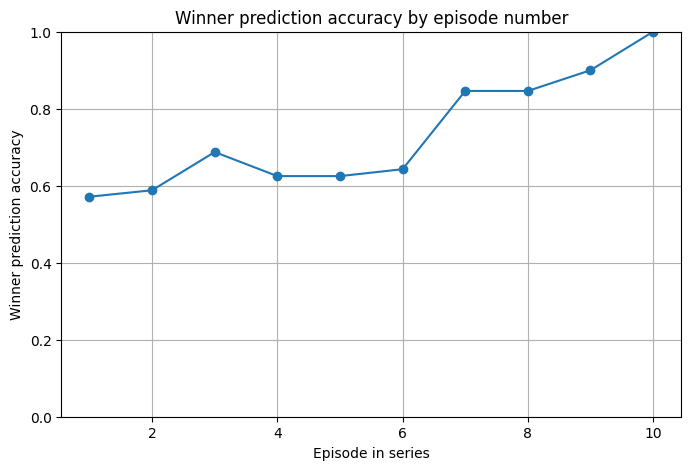

In [31]:
# Plot accuracy by raw episode

plt.figure(figsize=(8, 5))
plt.plot(
    accuracy_by_episode["episode_in_series"],
    accuracy_by_episode["winner_accuracy"],
    marker="o"
)

plt.xlabel("Episode in series")
plt.ylabel("Winner prediction accuracy")
plt.title("Winner prediction accuracy by episode number")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

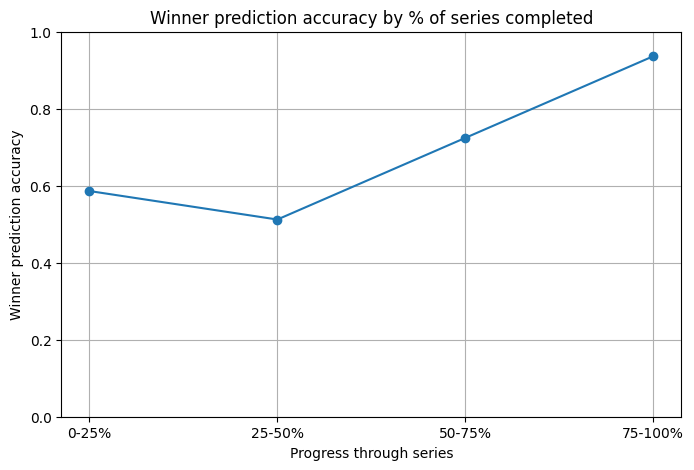

In [32]:
# Plot accuracy by series progress

plt.figure(figsize=(8, 5))
plt.plot(
    accuracy_by_progress["progress_bucket"].astype(str),
    accuracy_by_progress["winner_accuracy"],
    marker="o"
)

plt.xlabel("Progress through series")
plt.ylabel("Winner prediction accuracy")
plt.title("Winner prediction accuracy by % of series completed")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

## 🙋‍♀️ Observations: Final model prediction

### 📊 Winner prediction over time

The Ridge model was used to predict each contestant’s final score at the end of every episode, and these predictions were converted into a winner prediction by ranking contestants within each series.

Overall, the model demonstrates strong performance in identifying the eventual winner - and, importantly, does so surprisingly early in the series.

In the first quarter of a series, the model correctly identifies the winner around 60% of the time. This suggests that early performance already contains meaningful signal about final outcomes.

However, accuracy dips slightly in the middle of the series, reflecting a period where the competition remains uncertain and rankings are more volatile. This aligns with the nature of Taskmaster, where contestants often have inconsistent performances and positions shift before stabilising.

From the halfway point onwards, prediction accuracy improves significantly. By the final quarter of the series, the model correctly identifies the winner in over 90% of cases.

👉 **Overall, this suggests that while Taskmaster retains some unpredictability, the eventual winner is often determined - or at least strongly implied - by performance patterns established relatively early in the series.**

----

### 🎬 Interpreting results in context

It’s important to note that Taskmaster is not a purely live or randomly structured competition. Episodes are edited for entertainment, with tasks and performances sequenced to create engaging story arcs.

This means the dataset reflects not only contestant performance, but also editorial decisions about pacing, tension, and narrative progression.

As a result, some of the early predictive signal identified by the model may be influenced by how the show is structured - for example, how contestants are introduced, or how standout performances are distributed across episodes.

Similarly, the mid-series dip in prediction accuracy may reflect a deliberate increase in perceived unpredictability, while the strong late-series accuracy aligns with both genuine performance separation and narrative resolution.

🔍 **The winner of Taskmaster is often visible earlier than it feels - even if the show keeps things entertainingly uncertain along the way.**

### Limitations & next steps

This approach frames winner prediction as a function of observed performance within a series. While this produces strong results, there are a few important limitations to consider.

First, the model is trained and evaluated on historical series data, meaning it benefits from patterns that are consistent across past seasons. It does not yet simulate how a new, unseen series might unfold.

Second, several of the features used (such as cumulative score, recent averages, and current rank) are closely related. While Ridge Regression helps manage this, it means the model is effectively combining overlapping signals rather than learning entirely independent drivers of success.

Third, the dataset reflects an edited television programme rather than a purely live competition. As a result, some of the predictive signal may be influenced by how episodes are structured and presented, not just underlying performance.

Finally, this approach predicts final outcomes directly, rather than modelling how scores evolve over time. This limits its ability to simulate alternative scenarios or generate forward-looking predictions.

Future iterations could extend this work by:

- Simulating episode-by-episode performance for a new series
- Introducing probabilistic predictions (e.g. win likelihood rather than a single winner)
- Exploring simpler or more interpretable feature sets
- Testing performance on a held-out “new series” style split

## What's next

This approach predicts final outcomes based on observed performance within a series. However, it does not model how a new series might unfold.

In the next stage of the project, I extend this work by simulating episode-by-episode performance to estimate win probabilities for contestants in a new series.

## Exporting artefacts

In [33]:
contestant_stats = (
    snapshot_df.groupby(["series_id", "contestant"])
    .agg(
        mean_score=("episode_score", "mean"),
        std_score=("episode_score", "std")
    )
    .reset_index()
)

contestant_stats.to_csv("../data/processed/contestant_stats.csv", index=False)

In [34]:
snapshot_df.to_csv("../data/processed/snapshot_df.csv", index=False)

In [36]:
os.makedirs("../models", exist_ok=True)

joblib.dump(ridge_model, "../models/ridge_model.pkl")

['../models/ridge_model.pkl']